# 🗂️ DocClassify — Classification Automatique de Documents Bilingues (Arabe / Français)

**Catégories :** culture · finance · medical · politics · sports · tech
**Modèles comparés :**
- **Baseline** : TF-IDF (n-grammes de caractères) + SVM linéaire
- **Modèle principal** : XLM-RoBERTa-base (fine-tuning)

**Corpus :** `Corpus_12k` — 12 000 documents bilingues (arabe / français), avec une colonne `lang` déjà renseignée.

---

Ce notebook regroupe, dans un pipeline reproductible, l'ensemble du travail expérimental du
système *DocClassify* : chargement et exploration du corpus, prétraitement, encodage et découpage des
données (étapes communes aux deux modèles), puis l'entraînement et l'évaluation des deux approches,
y compris une analyse comparée par langue.


## 1. Installation des dépendances

In [1]:
%%capture
!pip install -q scikit-learn imbalanced-learn pyarabic emoji seaborn matplotlib pandas numpy
!pip install -q transformers[torch] datasets accelerate


## 2. Imports & configuration globale

In [2]:
import os, re, html, warnings, unicodedata, io, pickle, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay)

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

CATEGORIES = ["culture", "finance", "medical", "politics", "sports", "tech"]
LABEL2ID   = {l: i for i, l in enumerate(CATEGORIES)}
ID2LABEL   = {i: l for l, i in LABEL2ID.items()}

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Catégories :", CATEGORIES)
print(f"Device : {device.upper()}")

results = {}  # métriques des deux modèles, pour la comparaison finale


Catégories : ['culture', 'finance', 'medical', 'politics', 'sports', 'tech']
Device : CUDA


## 3. Chargement du corpus

In [4]:
CSV_PATH = 'Data/Corpus_12k.csv'

df = pd.read_csv(CSV_PATH)
print(f"Dimensions du corpus : {df.shape[0]} documents, {df.shape[1]} colonnes")
df.head()


Dimensions du corpus : 12000 documents, 3 colonnes


,text,label,lang
0,أبوظبي «الخليج»: ارتفع مؤشر سوق الإمارات المال...,Finance,ar
1,Beaucoup de critiques et d'intellectuels se re...,Culture,fr
2,شهد سوق دبي المالي تداولات بقيمة 750 .260 مليو...,Finance,ar
3,Le Conseil consultatif de Bahreïn a rejeté les...,Politics,fr
4,كتب الفيلسوف أورتيجا غاسيت ذات يوم أنا نتاج نف...,Culture,ar


## 4. Exploration du corpus (EDA)

Avant tout nettoyage, on vérifie l'équilibre des classes, la répartition entre les deux langues
(colonne `lang`, déjà présente dans le corpus) et la distribution de la longueur des documents —
trois facteurs qui influencent le choix de `max_features` (TF-IDF) et `max_length` (XLM-RoBERTa).


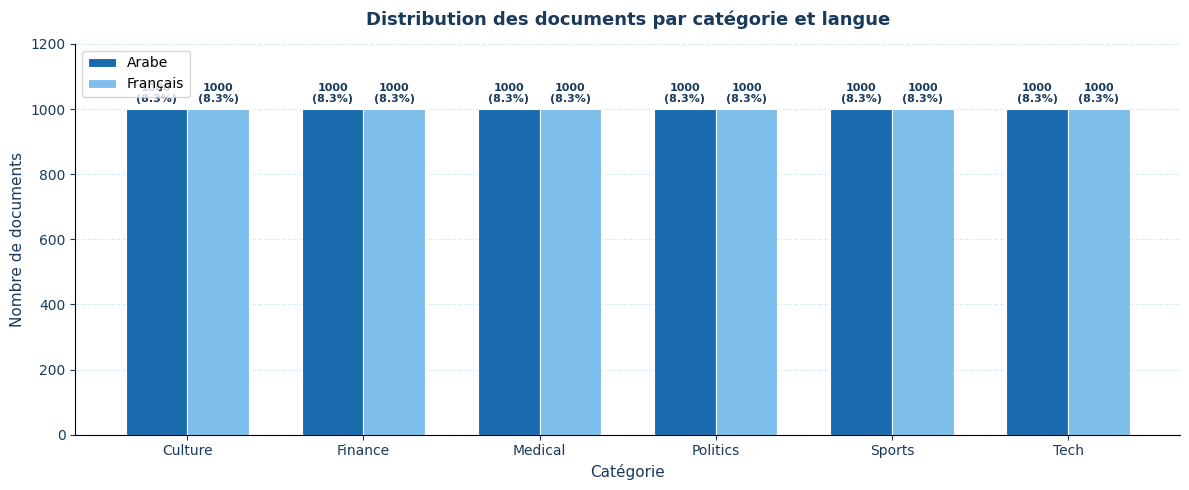

          Arabe  Français  Total  % Arabe  % Français
Culture    1000      1000   2000     50.0        50.0
Finance    1000      1000   2000     50.0        50.0
Medical    1000      1000   2000     50.0        50.0
Politics   1000      1000   2000     50.0        50.0
Sports     1000      1000   2000     50.0        50.0
Tech       1000      1000   2000     50.0        50.0


In [5]:
# La langue de chaque document est déjà indiquée par la colonne `lang` du corpus.
# On uniformise juste sa casse pour retomber sur les valeurs 'Arabic' / 'French'.
df['lang'] = df['lang'].astype(str).str.strip().str.capitalize()
df['lang'] = df['lang'].replace({
    'Ar': 'Arabic', 'Arabe': 'Arabic',
    'Fr': 'French', 'Français': 'French', 'Francais': 'French',
})

# ── Distribution des classes par langue ──────────────────────────────────
cats = sorted(df['label'].unique())
ar_counts = [len(df[(df['label'] == cat) & (df['lang'] == 'Arabic')]) for cat in cats]
fr_counts = [len(df[(df['label'] == cat) & (df['lang'] == 'French')]) for cat in cats]
total = len(df)

x = np.arange(len(cats))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, ar_counts, width, label='Arabe', color='#1a6bad', edgecolor='white', linewidth=0.8)
bars2 = ax.bar(x + width/2, fr_counts, width, label='Français', color='#7dbfea', edgecolor='white', linewidth=0.8)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            pct = height / total * 100
            ax.text(bar.get_x() + bar.get_width()/2, height + 15, f'{int(height)}\n({pct:.1f}%)',
                    ha='center', va='bottom', fontsize=8, color='#1a3a5c', fontweight='bold')

ax.set_xlabel("Catégorie", fontsize=11, color='#1a3a5c')
ax.set_ylabel("Nombre de documents", fontsize=11, color='#1a3a5c')
ax.set_title("Distribution des documents par catégorie et langue", fontsize=13, fontweight='bold', color='#1a3a5c', pad=14)
ax.set_xticks(x)
ax.set_xticklabels(cats, fontsize=10)
ax.legend(fontsize=10, loc='upper left')
ax.set_ylim(0, max(max(ar_counts), max(fr_counts)) * 1.2)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(colors='#1a3a5c')
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#c0d8f0')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('01_class_distribution_bylang.png', dpi=150, bbox_inches='tight')
plt.show()

summary_df = pd.DataFrame({'Arabe': ar_counts, 'Français': fr_counts}, index=cats)
summary_df['Total'] = summary_df.sum(axis=1)
summary_df['% Arabe'] = (summary_df['Arabe'] / summary_df['Total'] * 100).round(1)
summary_df['% Français'] = (summary_df['Français'] / summary_df['Total'] * 100).round(1)
print(summary_df.to_string())


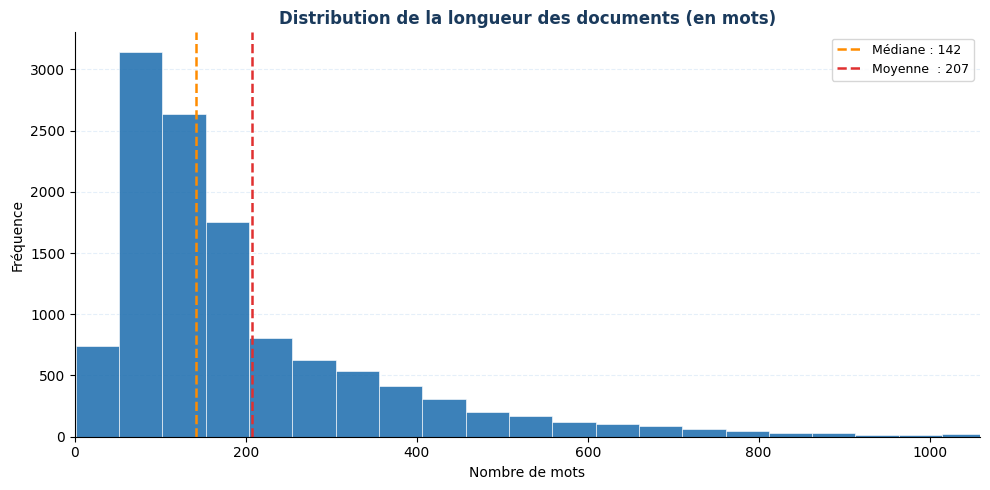

count    12000.000000
mean       207.496917
std        207.490491
min          1.000000
25%         89.000000
50%        142.000000
75%        248.000000
max       3042.000000
Name: text_length, dtype: float64


In [6]:
# Distribution de la longueur des textes (en mots), utile pour max_features / max_length.
df["text_length"] = df["text"].astype(str).apply(lambda t: len(t.split()))

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['text_length'], bins=60, color='#1a6bad', edgecolor='white', linewidth=0.5, alpha=0.85)
ax.axvline(df['text_length'].median(), color='#ff8c00', linestyle='--', linewidth=1.8,
           label=f'Médiane : {df["text_length"].median():.0f}')
ax.axvline(df['text_length'].mean(), color='#e03030', linestyle='--', linewidth=1.8,
           label=f'Moyenne  : {df["text_length"].mean():.0f}')

ax.set_xlim(0, df['text_length'].quantile(0.99))  # ignore les rares valeurs extrêmes
ax.set_title("Distribution de la longueur des documents (en mots)", fontsize=12, fontweight='bold', color='#1a3a5c')
ax.set_xlabel("Nombre de mots", fontsize=10)
ax.set_ylabel("Fréquence", fontsize=10)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#c0d8f0')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('02_text_length.png', dpi=150, bbox_inches='tight')
plt.show()

print(df['text_length'].describe())


## 5. Nettoyage & normalisation des textes

In [7]:
def normalize_common_text(text):
    """Nettoyage commun (HTML, URLs, espaces, minuscules), appliqué avant les deux modèles."""
    text = str(text)
    text = html.unescape(text)
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)
    text = re.sub(r"@\w+|#", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.lower()

def normalize_tfidf_text(text):
    """Normalisation additionnelle réservée au TF-IDF (arabe + accents français)."""
    text = normalize_common_text(text)

    # Arabe : tatweel, variantes d'alef, ta marbouta, alif maqsura, diacritiques
    text = re.sub(r"ـ", "", text)
    text = re.sub(r"[إأآا]", "ا", text)
    text = re.sub(r"ة", "ه", text)
    text = re.sub(r"ى", "ي", text)
    text = re.sub(r"[\u064B-\u0652]", "", text)

    # Français : suppression des accents
    text = unicodedata.normalize("NFKD", text)
    text = "".join(c for c in text if not unicodedata.combining(c))
    return unicodedata.normalize("NFC", text)

df["text_common"] = df["text"].apply(normalize_common_text)
df["text_tfidf"]  = df["text_common"].apply(normalize_tfidf_text)
df["text_xlmr"]   = df["text_common"]  # XLM-R garde accents et diacritiques

print("Exemple :")
print("Original :", df["text"].iloc[1][:120])
print("Commun   :", df["text_xlmr"].iloc[1][:120])
print("TF-IDF   :", df["text_tfidf"].iloc[1][:120])


Exemple :
Original : Beaucoup de critiques et d'intellectuels se rendent face à la réalité, à la fin de l'ère des grandes révolutions, pensan
Commun   : beaucoup de critiques et d'intellectuels se rendent face à la réalité, à la fin de l'ère des grandes révolutions, pensan
TF-IDF   : beaucoup de critiques et d'intellectuels se rendent face a la realite, a la fin de l'ere des grandes revolutions, pensan


## 6. Encodage des labels

In [8]:
df["label"] = df["label"].astype(str).str.strip().str.lower()
df["label_id"] = df["label"].map(LABEL2ID)

assert df["label_id"].isnull().sum() == 0, "Labels inconnus détectés dans le corpus !"

print("✅ Encodage OK")
print(df[["label", "label_id"]].drop_duplicates().sort_values("label_id").to_string(index=False))


✅ Encodage OK
   label  label_id
 culture         0
 finance         1
 medical         2
politics         3
  sports         4
    tech         5


## 7. Séparation Train / Validation / Test

In [9]:
# Split stratifié 70 / 15 / 15, partagé par les deux modèles pour rester comparables.
idx_all = np.arange(len(df))
y_all   = df["label_id"].values

idx_tv, idx_test = train_test_split(idx_all, test_size=0.15, stratify=y_all, random_state=SEED)
idx_train, idx_val = train_test_split(idx_tv, test_size=0.15/0.85, stratify=y_all[idx_tv], random_state=SEED)

df_train = df.iloc[idx_train].reset_index(drop=True)
df_val   = df.iloc[idx_val].reset_index(drop=True)
df_test  = df.iloc[idx_test].reset_index(drop=True)

print(f"Train : {len(df_train)} documents")
print(f"Val   : {len(df_val)} documents")
print(f"Test  : {len(df_test)} documents")


Train : 8399 documents
Val   : 1801 documents
Test  : 1800 documents


## 8. Modèle A — Baseline : TF-IDF + SVM

Le vectoriseur TF-IDF utilise des **n-grammes de caractères** (`char_wb`, 2 à 5 caractères)
plutôt que des n-grammes de mots, pour fonctionner de façon homogène sur l'arabe et le français
sans tokenisation spécifique à chaque langue. Le classifieur est un `LinearSVC`.


In [10]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
import resource

svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5),
                               max_features=60_000, sublinear_tf=True)),
    ("clf", LinearSVC(C=0.5, max_iter=2000, random_state=SEED))
])

_mem_before_svm = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
_t0_svm = time.time()
svm_pipeline.fit(df_train["text_tfidf"], df_train["label_id"])
train_time_svm = time.time() - _t0_svm
train_mem_mb_svm = max(resource.getrusage(resource.RUSAGE_SELF).ru_maxrss - _mem_before_svm, 0) / 1024

y_pred_svm = svm_pipeline.predict(df_test["text_tfidf"])
y_true_svm = df_test["label_id"].values

print("=== Baseline TF-IDF + SVM ===")
print(classification_report(y_true_svm, y_pred_svm, target_names=CATEGORIES, digits=4))
print(f"Temps d'entraînement : {train_time_svm:.2f} s")

results["TF-IDF + SVM"] = {
    "accuracy"    : accuracy_score(y_true_svm, y_pred_svm),
    "f1_macro"    : f1_score(y_true_svm, y_pred_svm, average="macro"),
    "f1_weighted" : f1_score(y_true_svm, y_pred_svm, average="weighted"),
    "precision"   : precision_score(y_true_svm, y_pred_svm, average="macro"),
    "recall"      : recall_score(y_true_svm, y_pred_svm, average="macro"),
}
print(results["TF-IDF + SVM"])


=== Baseline TF-IDF + SVM ===
              precision    recall  f1-score   support

     culture     0.9638    0.9767    0.9702       300
     finance     0.9932    0.9667    0.9797       300
     medical     0.9662    0.9533    0.9597       300
    politics     0.9641    0.9833    0.9736       300
      sports     0.9865    0.9767    0.9816       300
        tech     0.9344    0.9500    0.9421       300

    accuracy                         0.9678      1800
   macro avg     0.9680    0.9678    0.9678      1800
weighted avg     0.9680    0.9678    0.9678      1800

Temps d'entraînement : 41.75 s
{'accuracy': 0.9677777777777777, 'f1_macro': 0.9678301013801026, 'f1_weighted': 0.9678301013801026, 'precision': 0.9680321990405484, 'recall': 0.9677777777777777}


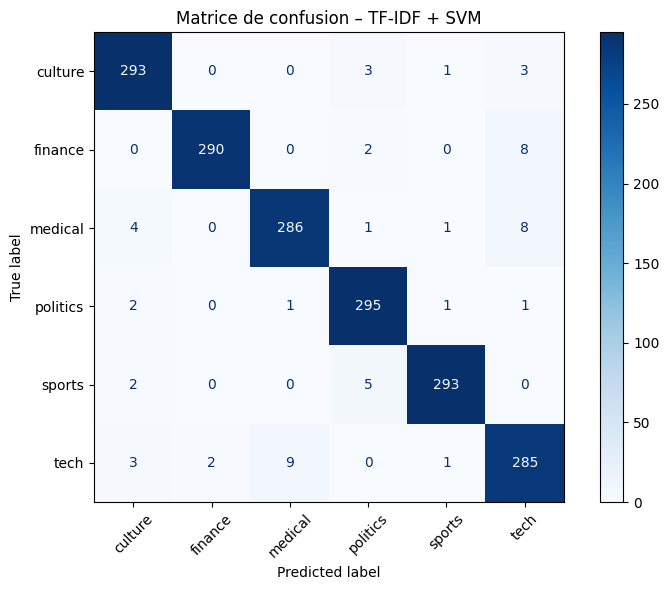

In [11]:
plt.figure(figsize=(8, 6))
cm_svm = confusion_matrix(y_true_svm, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=CATEGORIES)
disp.plot(cmap="Blues", values_format="d", ax=plt.gca())
plt.title("Matrice de confusion – TF-IDF + SVM")
plt.xticks(rotation=45)
plt.grid(False)
plt.tight_layout()
plt.show()


### 8.1 Efficacité computationnelle — TF-IDF + SVM

In [12]:
sample_texts_svm = df_test["text_tfidf"].sample(n=min(200, len(df_test)), random_state=SEED).tolist()

for t in sample_texts_svm[:5]:          # warm-up
    svm_pipeline.predict([t])

latencies_svm = []
for t in sample_texts_svm:
    t0 = time.time()
    svm_pipeline.predict([t])
    latencies_svm.append((time.time() - t0) * 1000)  # ms
latency_svm_mean = np.mean(latencies_svm)

t0 = time.time()
_ = svm_pipeline.predict(df_test["text_tfidf"])
throughput_svm = len(df_test) / (time.time() - t0)

model_buffer_svm = io.BytesIO()
pickle.dump(svm_pipeline, model_buffer_svm)
model_size_svm_mb = len(model_buffer_svm.getvalue()) / (1024 ** 2)

print("=== Efficacité computationnelle — TF-IDF + SVM ===")
print(f"Temps d'entraînement          : {train_time_svm:.2f} s")
print(f"Latence d'inférence (batch=1) : {latency_svm_mean:.2f} ms")
print(f"Débit (jeu de test complet)   : {throughput_svm:.1f} documents/s")
print(f"Taille du modèle sérialisé    : {model_size_svm_mb:.1f} Mo")


=== Efficacité computationnelle — TF-IDF + SVM ===
Temps d'entraînement          : 41.75 s
Latence d'inférence (batch=1) : 3.74 ms
Débit (jeu de test complet)   : 294.4 documents/s
Taille du modèle sérialisé    : 4.9 Mo


## 9. Modèle B — Fine-tuning de XLM-RoBERTa

On entraîne un **XLM-RoBERTa-base** sur exactement les mêmes `df_train` / `df_val` / `df_test`
que la baseline, avec un correctif de compatibilité `torchvision`, une tokenisation dédiée,
des taux d'apprentissage différenciés par couche et un scheduler cosine.


In [13]:
import torchvision.io as _tvio
if not hasattr(_tvio, "VideoReader"):
    class VideoReader:
        pass
    _tvio.VideoReader = VideoReader


### 9.1 Tokenisation et construction des `Dataset` Hugging Face

In [14]:
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           TrainingArguments, Trainer, DataCollatorWithPadding,
                           EarlyStoppingCallback, get_cosine_schedule_with_warmup)
from datasets import Dataset

MODEL_NAME = "xlm-roberta-base"
tok_xlmr = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_xlmr(batch):
    # Troncature à 256 tokens ; le padding dynamique est géré par le DataCollator.
    return tok_xlmr(batch["text_xlmr"], truncation=True, max_length=256, padding=False)

def make_dataset(df_):
    ds = Dataset.from_pandas(df_[["text_xlmr", "label_id"]].rename(columns={"label_id": "labels"}))
    ds = ds.map(tokenize_xlmr, batched=True, batch_size=256)
    ds.set_format("torch")
    return ds

print("Préparation des datasets...")
train_ds = make_dataset(df_train)
val_ds   = make_dataset(df_val)
test_ds  = make_dataset(df_test)
print(f"Train : {len(train_ds)} | Val : {len(val_ds)} | Test : {len(test_ds)}")


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Préparation des datasets...


Map:   0%|          | 0/8399 [00:00<?, ? examples/s]

Map:   0%|          | 0/1801 [00:00<?, ? examples/s]

Map:   0%|          | 0/1800 [00:00<?, ? examples/s]

Train : 8399 | Val : 1801 | Test : 1800


### 9.2 Instanciation du modèle

In [15]:
model_xlmr = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(CATEGORIES), id2label=ID2LABEL, label2id=LABEL2ID
)


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### 9.3 Métriques et hyperparamètres d'entraînement

Le F1-macro sert de critère de sélection du meilleur modèle, plus robuste que l'accuracy
en cas de léger déséquilibre entre classes.


In [19]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy"   : accuracy_score(labels, preds),
        "f1_macro"   : f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
        "precision"  : precision_score(labels, preds, average="macro"),
        "recall"     : recall_score(labels, preds, average="macro"),
    }

training_args = TrainingArguments(
    output_dir="./results_xlm_roberta",
    label_smoothing_factor=0.1,
    learning_rate=2e-5,                  # Taux classique pour le fine-tuning de Transformers
    per_device_train_batch_size=16,      # À baisser à 8 si vous saturez la VRAM
    per_device_eval_batch_size=16,
    num_train_epochs=3,                  # 3 époques suffisent généralement
    weight_decay=0.01,
    eval_strategy="epoch",               # Évaluation à la fin de chaque époque
    save_strategy="epoch",               # Sauvegarde des checkpoints cohérente avec l'évaluation
    load_best_model_at_end=True,         # Charge automatiquement le meilleur modèle trouvé
    metric_for_best_model="eval_f1_macro",  # Le F1-score est plus robuste que l'accuracy si les classes sont déséquilibrées

    logging_steps=100,
    report_to="none"                     # Désactive les logs externes type Wandb
)



### 9.4 Taux d'apprentissage différenciés et scheduler cosine

Les couches basses (embeddings) reçoivent un taux d'apprentissage plus faible que les couches
hautes et la tête de classification, pour préserver les représentations générales de XLM-R.


In [20]:
optimizer = optim.AdamW([
    {"params": model_xlmr.roberta.embeddings.parameters(),          "lr": 2e-6},
    {"params": model_xlmr.roberta.encoder.layer[:4].parameters(),   "lr": 8e-6},
    {"params": model_xlmr.roberta.encoder.layer[4:8].parameters(),  "lr": 1.2e-5},
    {"params": model_xlmr.roberta.encoder.layer[8:].parameters(),   "lr": 1.8e-5},
    {"params": model_xlmr.classifier.parameters(),                  "lr": 3e-5},
], weight_decay=0.01)

num_steps = (len(train_ds) // training_args.per_device_train_batch_size) * training_args.num_train_epochs
warmup = int(0.1 * num_steps)

scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=warmup, num_training_steps=num_steps)


## 10. Entraînement du modèle XLM-RoBERTa

`EarlyStoppingCallback` (patience de 3 évaluations) arrête l'entraînement si le F1-macro
de validation stagne.


In [21]:
trainer = Trainer(
    model=model_xlmr,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tok_xlmr,
    data_collator=DataCollatorWithPadding(tok_xlmr),
    compute_metrics=compute_metrics,
    optimizers=(optimizer, scheduler),
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

_t0_xlmr = time.time()
train_result = trainer.train()
train_time_xlmr = time.time() - _t0_xlmr

if torch.cuda.is_available():
    train_mem_mb_xlmr = torch.cuda.max_memory_allocated() / (1024 ** 2)
else:
    train_mem_mb_xlmr = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024

print("\n✅ Entraînement XLM-RoBERTa terminé !")
print(f"Temps d'entraînement : {train_time_xlmr/60:.1f} min ({train_time_xlmr:.0f} s)")


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision,Recall
1,0.512994,0.509170,0.966685,0.966670,0.966664,0.967271,0.966700
2,0.475194,0.496155,0.971127,0.971100,0.971092,0.971197,0.971139
3,0.463236,0.496873,0.973348,0.973333,0.973325,0.973390,0.973359


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Entraînement XLM-RoBERTa terminé !
Temps d'entraînement : 25.1 min (1506 s)


## 11. Évaluation de XLM-RoBERTa sur le jeu de test

In [22]:
preds_out   = trainer.predict(test_ds)
y_pred_xlmr = np.argmax(preds_out.predictions, axis=-1)
y_true_xlmr = np.array(test_ds["labels"])

print("=== XLM-RoBERTa ===")
print(classification_report(y_true_xlmr, y_pred_xlmr, target_names=CATEGORIES, digits=4))

results["XLM-RoBERTa"] = {
    "accuracy"   : accuracy_score(y_true_xlmr, y_pred_xlmr),
    "f1_macro"   : f1_score(y_true_xlmr, y_pred_xlmr, average="macro"),
    "f1_weighted": f1_score(y_true_xlmr, y_pred_xlmr, average="weighted"),
    "precision"  : precision_score(y_true_xlmr, y_pred_xlmr, average="macro"),
    "recall"     : recall_score(y_true_xlmr, y_pred_xlmr, average="macro"),
}
print(results["XLM-RoBERTa"])


=== XLM-RoBERTa ===
              precision    recall  f1-score   support

     culture     0.9737    0.9867    0.9801       300
     finance     0.9832    0.9767    0.9799       300
     medical     0.9704    0.9833    0.9768       300
    politics     0.9831    0.9700    0.9765       300
      sports     0.9868    0.9933    0.9900       300
        tech     0.9764    0.9633    0.9698       300

    accuracy                         0.9789      1800
   macro avg     0.9789    0.9789    0.9789      1800
weighted avg     0.9789    0.9789    0.9789      1800

{'accuracy': 0.9788888888888889, 'f1_macro': 0.9788714500292626, 'f1_weighted': 0.9788714500292626, 'precision': 0.9789191417042277, 'recall': 0.9788888888888888}


### 11.1 Courbes d'apprentissage et matrice de confusion

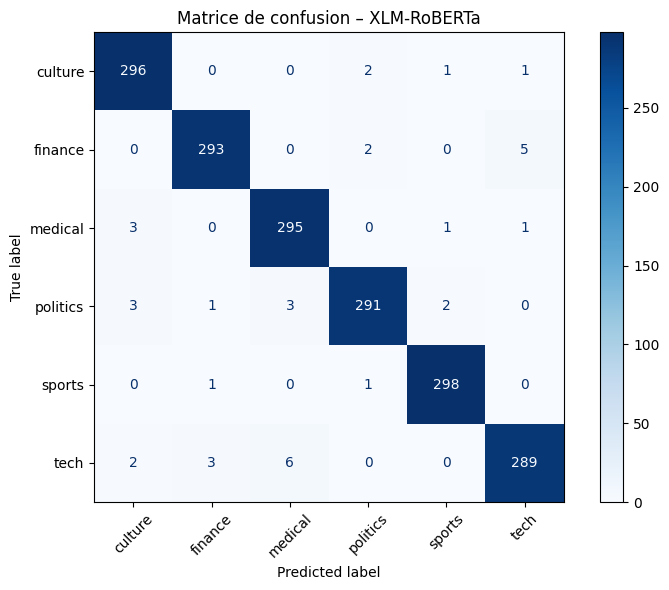

In [23]:
history = trainer.state.log_history
eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]

plt.figure(figsize=(8, 6))
cm_xlmr = confusion_matrix(y_true_xlmr, y_pred_xlmr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xlmr, display_labels=CATEGORIES)
disp.plot(cmap="Blues", values_format="d", ax=plt.gca())
plt.title("Matrice de confusion – XLM-RoBERTa")
plt.xticks(rotation=45)
plt.grid(False)
plt.tight_layout()
plt.show()


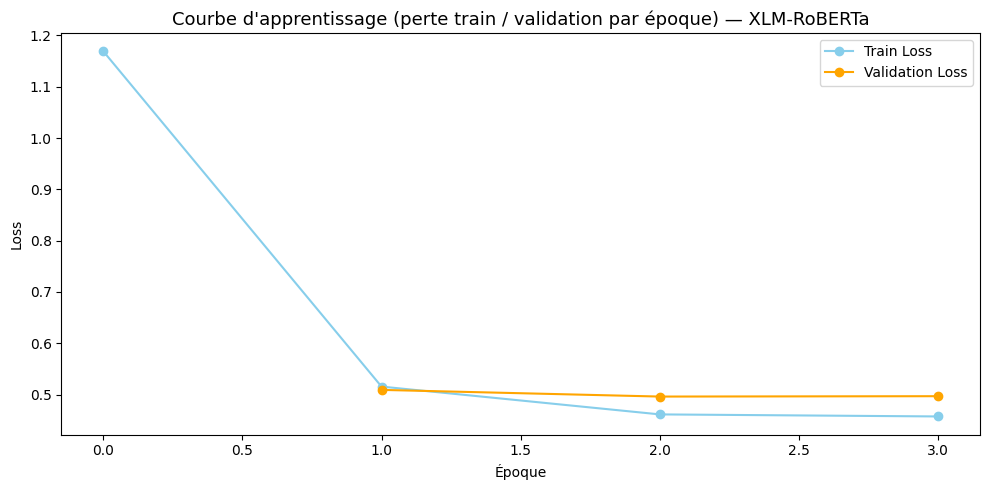

In [24]:
train_loss_by_epoch = {}
for x in history:
    if "loss" in x and "epoch" in x:
        ep = round(x["epoch"])
        train_loss_by_epoch.setdefault(ep, []).append(x["loss"])
train_epochs = sorted(train_loss_by_epoch)
train_loss_per_epoch = [np.mean(train_loss_by_epoch[e]) for e in train_epochs]
eval_epochs = list(range(1, len(eval_loss) + 1))

plt.figure(figsize=(10, 5))
plt.plot(train_epochs, train_loss_per_epoch, label='Train Loss', marker='o', color='#87CEEB')
plt.plot(eval_epochs, eval_loss, label='Validation Loss', marker='o', color='#FFA500')
plt.title("Courbe d'apprentissage (perte train / validation par époque) — XLM-RoBERTa", fontsize=13)
plt.xlabel('Époque')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig('11_train_val_loss_xlmr.png', dpi=150, bbox_inches='tight')
plt.show()


### 11.2 Efficacité computationnelle — XLM-RoBERTa

Latence d'inférence document par document, débit sur le jeu de test, empreinte mémoire GPU
(ou CPU à défaut) et taille du modèle sérialisé.


In [25]:
model_xlmr.eval()
model_xlmr.to(device)

sample_texts_xlmr = df_test["text"].sample(n=min(200, len(df_test)), random_state=SEED).tolist()

def predict_one_xlmr(text):
    enc = tok_xlmr(text, truncation=True, max_length=256, padding=False, return_tensors="pt").to(device)
    with torch.no_grad():
        _ = model_xlmr(**enc)

for t in sample_texts_xlmr[:5]:          # warm-up
    predict_one_xlmr(t)
if device == "cuda":
    torch.cuda.synchronize()

latencies_xlmr = []
for text in sample_texts_xlmr:
    if device == "cuda":
        torch.cuda.synchronize()
    t0 = time.time()
    predict_one_xlmr(text)
    if device == "cuda":
        torch.cuda.synchronize()
    latencies_xlmr.append((time.time() - t0) * 1000)  # ms

latency_xlmr_mean   = np.mean(latencies_xlmr)
latency_xlmr_median = np.median(latencies_xlmr)

t0 = time.time()
_ = trainer.predict(test_ds)
throughput_xlmr = len(df_test) / (time.time() - t0)

model_buffer_xlmr = io.BytesIO()
torch.save(model_xlmr.state_dict(), model_buffer_xlmr)
model_size_xlmr_mb = len(model_buffer_xlmr.getvalue()) / (1024 ** 2)
n_params_xlmr = sum(p.numel() for p in model_xlmr.parameters())

print("=== Efficacité computationnelle — XLM-RoBERTa ===")
print(f"Temps d'entraînement             : {train_time_xlmr/60:.1f} min ({train_time_xlmr:.0f} s)")
mem_label = "Mémoire GPU pic" if device == "cuda" else "Mémoire RSS"
print(f"{mem_label} pendant l'entraînement : {train_mem_mb_xlmr:.1f} Mo")
print(f"Latence d'inférence (batch=1)     : {latency_xlmr_mean:.2f} ms (médiane : {latency_xlmr_median:.2f} ms)")
print(f"Débit (jeu de test complet)       : {throughput_xlmr:.1f} documents/s")
print(f"Nombre de paramètres              : {n_params_xlmr:,}")
print(f"Taille du modèle sérialisé        : {model_size_xlmr_mb:.1f} Mo")


=== Efficacité computationnelle — XLM-RoBERTa ===
Temps d'entraînement             : 25.1 min (1506 s)
Mémoire GPU pic pendant l'entraînement : 5782.8 Mo
Latence d'inférence (batch=1)     : 15.32 ms (médiane : 16.37 ms)
Débit (jeu de test complet)       : 72.8 documents/s
Nombre de paramètres              : 278,048,262
Taille du modèle sérialisé        : 1060.7 Mo


## 12. Comparaison quantitative des deux modèles

Les deux modèles sont entraînés et évalués sur des `df_train` / `df_val` / `df_test` strictement
identiques, ce qui rend leurs métriques directement comparables.


In [26]:
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df[["accuracy", "f1_macro", "f1_weighted", "precision", "recall"]]
comparison_df.columns = ["Accuracy", "F1-macro", "F1-pondéré", "Précision (macro)", "Rappel (macro)"]
comparison_df = (comparison_df * 100).round(2)

print("=== Comparaison des modèles (%) ===")
print(comparison_df.to_string())

delta_f1 = comparison_df.loc["XLM-RoBERTa", "F1-macro"] - comparison_df.loc["TF-IDF + SVM", "F1-macro"]
print(f"\nGain de XLM-RoBERTa sur la baseline (F1-macro) : {delta_f1:+.2f} points")


=== Comparaison des modèles (%) ===
              Accuracy  F1-macro  F1-pondéré  Précision (macro)  Rappel (macro)
TF-IDF + SVM     96.78     96.78       96.78              96.80           96.78
XLM-RoBERTa      97.89     97.89       97.89              97.89           97.89

Gain de XLM-RoBERTa sur la baseline (F1-macro) : +1.11 points


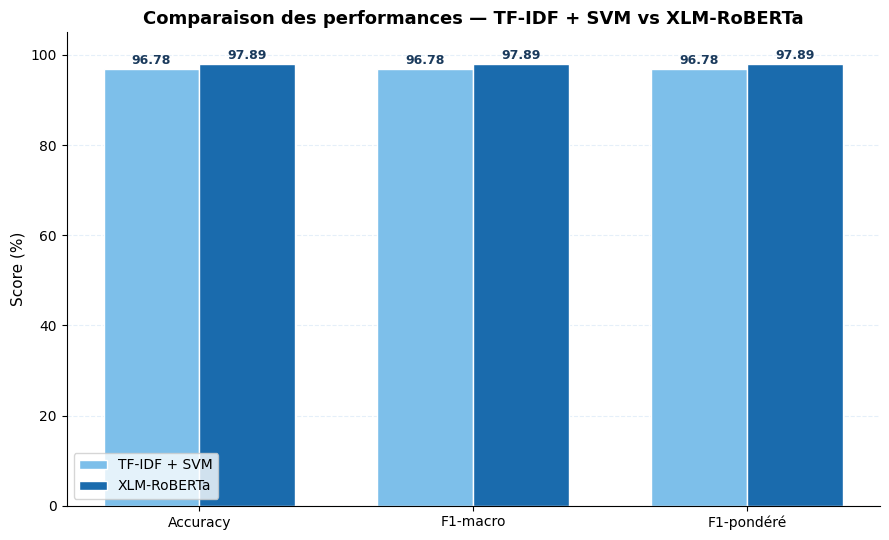

In [27]:
metrics_to_plot = ["Accuracy", "F1-macro", "F1-pondéré"]
x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5.5))
bars1 = ax.bar(x - width/2, comparison_df.loc["TF-IDF + SVM", metrics_to_plot], width,
               label="TF-IDF + SVM", color="#7dbfea", edgecolor="white")
bars2 = ax.bar(x + width/2, comparison_df.loc["XLM-RoBERTa", metrics_to_plot], width,
               label="XLM-RoBERTa", color="#1a6bad", edgecolor="white")

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, f"{height:.2f}",
                ha="center", va="bottom", fontsize=9, color="#1a3a5c", fontweight="bold")

ax.set_ylabel("Score (%)", fontsize=11)
ax.set_title("Comparaison des performances — TF-IDF + SVM vs XLM-RoBERTa", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, fontsize=10)
ax.set_ylim(0, 105)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.4, color="#c0d8f0")
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('03_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### 12.1 Matrices de confusion

Comparaison visuelle directe des matrices de confusion des deux modèles sur le même jeu de test.


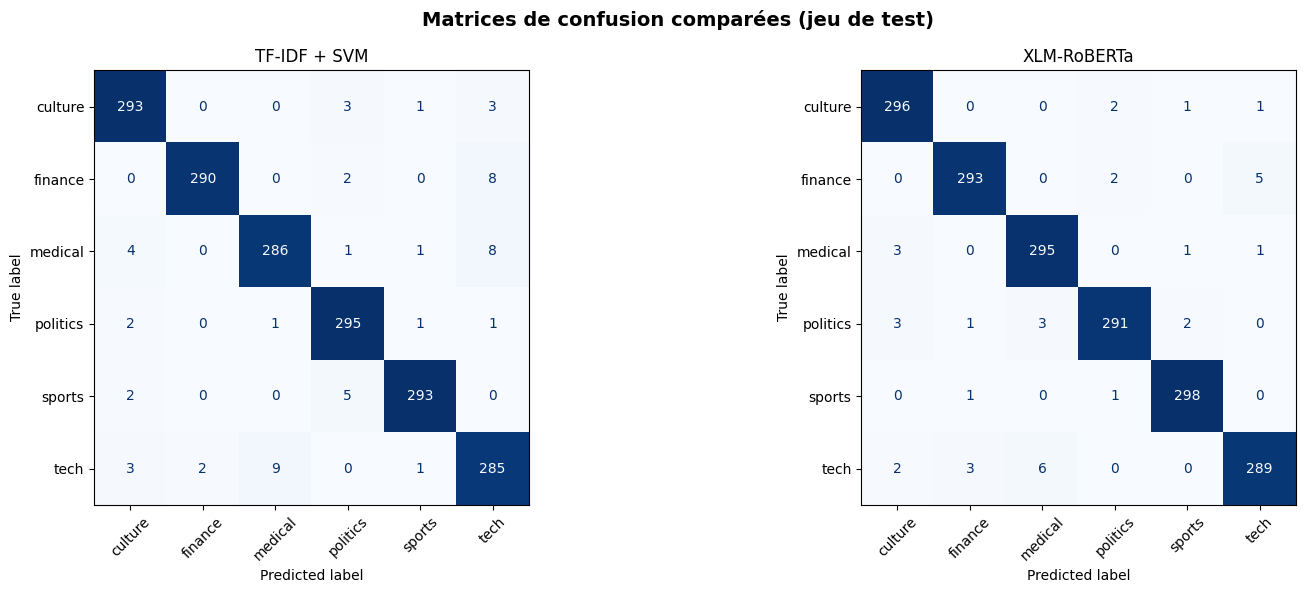

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=CATEGORIES)
disp1.plot(cmap="Blues", values_format="d", ax=axes[0], colorbar=False)
axes[0].set_title("TF-IDF + SVM")
axes[0].tick_params(axis='x', rotation=45)

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_xlmr, display_labels=CATEGORIES)
disp2.plot(cmap="Blues", values_format="d", ax=axes[1], colorbar=False)
axes[1].set_title("XLM-RoBERTa")
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle("Matrices de confusion comparées (jeu de test)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### 12.2 Analyse des performances par langue (Arabe vs Français)

On ventile les prédictions déjà calculées (`y_true_svm`/`y_pred_svm`, `y_true_xlmr`/`y_pred_xlmr`)
selon la colonne `lang` de `df_test`, issue directement du corpus.


In [29]:
def metrics_by_lang(y_true, y_pred, lang_array):
    """Accuracy / precision / recall / F1-macro séparément par langue."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    rows = {}
    for lang in ["Arabic", "French"]:
        mask = lang_array == lang
        yt, yp = y_true[mask], y_pred[mask]
        rows[lang] = {
            "n_docs"    : int(mask.sum()),
            "accuracy"  : accuracy_score(yt, yp),
            "precision" : precision_score(yt, yp, average="macro", zero_division=0),
            "recall"    : recall_score(yt, yp, average="macro", zero_division=0),
            "f1_macro"  : f1_score(yt, yp, average="macro", zero_division=0),
        }
    return rows

lang_test = df_test["lang"].values
svm_by_lang  = metrics_by_lang(y_true_svm, y_pred_svm, lang_test)
xlmr_by_lang = metrics_by_lang(y_true_xlmr, y_pred_xlmr, lang_test)

lang_results = {
    ("TF-IDF + SVM", "Arabe")    : svm_by_lang["Arabic"],
    ("TF-IDF + SVM", "Français") : svm_by_lang["French"],
    ("XLM-RoBERTa", "Arabe")     : xlmr_by_lang["Arabic"],
    ("XLM-RoBERTa", "Français")  : xlmr_by_lang["French"],
}

lang_comparison_df = pd.DataFrame(lang_results).T
lang_comparison_df = lang_comparison_df[["n_docs", "accuracy", "precision", "recall", "f1_macro"]]
lang_comparison_df.columns = ["N documents", "Accuracy", "Précision (macro)", "Rappel (macro)", "F1-macro"]
for col in ["Accuracy", "Précision (macro)", "Rappel (macro)", "F1-macro"]:
    lang_comparison_df[col] = (lang_comparison_df[col] * 100).round(2)
lang_comparison_df["N documents"] = lang_comparison_df["N documents"].astype(int)
lang_comparison_df.index = lang_comparison_df.index.set_names(["Modèle", "Langue"])

print("=== Performances ventilées par langue (Arabe vs Français) — jeu de test ===")
print(lang_comparison_df.to_string())
lang_comparison_df


=== Performances ventilées par langue (Arabe vs Français) — jeu de test ===
                       N documents  Accuracy  Précision (macro)  Rappel (macro)  F1-macro
Modèle       Langue                                                                      
TF-IDF + SVM Arabe             896     98.10              98.12           98.05     98.07
             Français          904     95.46              95.55           95.41     95.46
XLM-RoBERTa  Arabe             896     98.77              98.81           98.76     98.78
             Français          904     97.01              97.01           97.05     97.02


N documents  Accuracy  Précision (macro)  \
Modèle       Langue                                               
TF-IDF + SVM Arabe             896     98.10              98.12   
             Français          904     95.46              95.55   
XLM-RoBERTa  Arabe             896     98.77              98.81   
             Français          904     97.01              97.01   

                       Rappel (macro)  F1-macro  
Modèle       Langue                              
TF-IDF + SVM Arabe              98.05     98.07  
             Français           95.41     95.46  
XLM-RoBERTa  Arabe              98.76     98.78  
             Français           97.05     97.02

### 12.3 Efficacité computationnelle : synthèse

Regroupe les mesures de temps d'entraînement, latence, débit et taille de modèle des deux approches.


In [32]:
efficiency_results = {
    "TF-IDF + SVM": {
        "Temps entraînement (s)"     : train_time_svm,
        "Latence inférence (ms/doc)" : latency_svm_mean,
        "Débit (doc/s)"              : throughput_svm,
        "Taille modèle (Mo)"         : model_size_svm_mb,
    },
    "XLM-RoBERTa": {
        "Temps entraînement (s)"     : train_time_xlmr,
        "Latence inférence (ms/doc)" : latency_xlmr_mean,
        "Débit (doc/s)"              : throughput_xlmr,
        "Taille modèle (Mo)"         : model_size_xlmr_mb,
    },
}

efficiency_df = pd.DataFrame(efficiency_results).T.round(2)
print("=== Synthèse : efficacité computationnelle (jeu de test) ===")
print(efficiency_df.to_string())
efficiency_df


=== Synthèse : efficacité computationnelle (jeu de test) ===
              Temps entraînement (s)  Latence inférence (ms/doc)  Débit (doc/s)  Taille modèle (Mo)
TF-IDF + SVM                   41.75                        3.74         294.43                4.85
XLM-RoBERTa                  1505.56                       15.32          72.83             1060.75


,Temps entraînement (s),Latence inférence (ms/doc),Débit (doc/s),Taille modèle (Mo)
TF-IDF + SVM,41.75,3.74,294.43,4.85
XLM-RoBERTa,1505.56,15.32,72.83,1060.75


## 13. Test d'inférence comparatif sur des exemples multilingues

On applique les deux modèles entraînés aux mêmes phrases inédites, en français et en arabe.
`LinearSVC` n'ayant pas de `predict_proba`, un score de confiance approché est calculé via
une softmax sur ses scores de décision.


In [37]:
from transformers import pipeline as hf_pipeline

def predict_svm_with_confidence(text, pipeline, categories):
    """Prédit la catégorie avec la baseline et un score de confiance approché."""
    decision_scores = pipeline.decision_function([text])[0]
    exp_scores = np.exp(decision_scores - np.max(decision_scores))
    probabilities = exp_scores / exp_scores.sum()
    predicted_id = int(np.argmax(probabilities))
    return categories[predicted_id], float(probabilities[predicted_id])


xlmr_classifier = hf_pipeline(
    "text-classification",
    model=model_xlmr,
    tokenizer=tok_xlmr,
    device=0 if torch.cuda.is_available() else -1
)

MAX_TOKENS_BENCHMARK = 256

exemples_test = [
    ("Le nouveau vaccin contre le paludisme a montré une efficacité sans précédent lors des essais cliniques.", "medical"),
    ("La bourse de Paris a clôturé en forte hausse suite aux annonces de la banque centrale.", "finance"),
    ("L'équipe nationale a remporté la coupe du monde après un match exceptionnel et des tirs au but.", "sports"),
    ("أعلنت الشركة عن إطلاق هاتفها الذكي الجديد المزود بتقنية الذكاء الاصطناعي والكاميرا المتطورة.", "tech"),
    ("افتتح وزير الثقافة معرض الكتاب الدولي بحضور عدد كبير من الكتاب والروائيين من مختلف الدول.", "culture"),
]

print("--- TESTS D'INFÉRENCE MULTILINGUE COMPARATIFS ---\n")

comparison_rows = []

for text, expected_label in exemples_test:
    clean_text = normalize_common_text(text)

    n_tokens = len(
        tok_xlmr(
            clean_text,
            truncation=True,
            max_length=MAX_TOKENS_BENCHMARK
        )["input_ids"]
    )

    # Prédiction TF-IDF + SVM
    svm_label, svm_conf = predict_svm_with_confidence(
        clean_text,
        svm_pipeline,
        CATEGORIES
    )

    # Prédiction XLM-RoBERTa
    xlmr_out = xlmr_classifier(
        clean_text,
        truncation=True,
        max_length=MAX_TOKENS_BENCHMARK
    )[0]

    xlmr_label = xlmr_out["label"]
    xlmr_conf = xlmr_out["score"]

    svm_ok = "✅" if svm_label == expected_label else "❌"
    xlmr_ok = "✅" if xlmr_label == expected_label else "❌"

    print(f"Texte        : {text[:70]}...")
    print(f"Attendu      : {expected_label.upper()}")
    print(f"Tokens (≤{MAX_TOKENS_BENCHMARK}) : {n_tokens}")
    print(f"TF-IDF+SVM   : {svm_label.upper()} (Confiance : {svm_conf:.2%}) {svm_ok}")
    print(f"XLM-RoBERTa  : {xlmr_label.upper()} (Confiance : {xlmr_conf:.2%}) {xlmr_ok}\n")

    comparison_rows.append({
        "Texte": text[:60] + "...",
        "Attendu": expected_label,
        "Nb tokens": n_tokens,
        "TF-IDF+SVM": svm_label,
        "Conf. SVM": f"{svm_conf:.1%}",
        "XLM-RoBERTa": xlmr_label,
        "Conf. XLM-R": f"{xlmr_conf:.1%}"
    })

inference_comparison_df = pd.DataFrame(comparison_rows)

inference_comparison_df

--- TESTS D'INFÉRENCE MULTILINGUE COMPARATIFS ---

Texte        : Le nouveau vaccin contre le paludisme a montré une efficacité sans pré...
Attendu      : MEDICAL
Tokens (≤256) : 25
TF-IDF+SVM   : POLITICS (Confiance : 23.29%) ❌
XLM-RoBERTa  : MEDICAL (Confiance : 93.44%) ✅

Texte        : La bourse de Paris a clôturé en forte hausse suite aux annonces de la ...
Attendu      : FINANCE
Tokens (≤256) : 25
TF-IDF+SVM   : FINANCE (Confiance : 54.16%) ✅
XLM-RoBERTa  : FINANCE (Confiance : 92.83%) ✅

Texte        : L'équipe nationale a remporté la coupe du monde après un match excepti...
Attendu      : SPORTS
Tokens (≤256) : 26
TF-IDF+SVM   : SPORTS (Confiance : 51.01%) ✅
XLM-RoBERTa  : SPORTS (Confiance : 92.67%) ✅

Texte        : أعلنت الشركة عن إطلاق هاتفها الذكي الجديد المزود بتقنية الذكاء الاصطنا...
Attendu      : TECH
Tokens (≤256) : 30
TF-IDF+SVM   : TECH (Confiance : 46.90%) ✅
XLM-RoBERTa  : TECH (Confiance : 91.91%) ✅

Texte        : افتتح وزير الثقافة معرض الكتاب الدولي بحضور عدد ك

,Texte,Attendu,Nb tokens,TF-IDF+SVM,Conf. SVM,XLM-RoBERTa,Conf. XLM-R
0,Le nouveau vaccin contre le paludisme a montré...,medical,25,politics,23.3%,medical,93.4%
1,La bourse de Paris a clôturé en forte hausse s...,finance,25,finance,54.2%,finance,92.8%
2,L'équipe nationale a remporté la coupe du mond...,sports,26,sports,51.0%,sports,92.7%
3,أعلنت الشركة عن إطلاق هاتفها الذكي الجديد المز...,tech,30,tech,46.9%,tech,91.9%
4,افتتح وزير الثقافة معرض الكتاب الدولي بحضور عد...,culture,22,culture,71.0%,culture,92.4%
